In [ ]:
import numpy as np
import joblib
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

PROCESSED = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\data\processed"
RESULTS   = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\results"
MODELS    = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\models"

X_train = np.load(os.path.join(PROCESSED, "ciciomt2024_X_train.npy"))
X_val   = np.load(os.path.join(PROCESSED, "ciciomt2024_X_val.npy"))
X_test  = np.load(os.path.join(PROCESSED, "ciciomt2024_X_test.npy"))
y_train = np.load(os.path.join(PROCESSED, "ciciomt2024_y_train.npy"))
y_val   = np.load(os.path.join(PROCESSED, "ciciomt2024_y_val.npy"))
y_test  = np.load(os.path.join(PROCESSED, "ciciomt2024_y_test.npy"))
class_weights = joblib.load(os.path.join(PROCESSED, "ciciomt2024_class_weights.pkl"))

# Reshape for CNN
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_cnn   = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test_cnn  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"CNN input shape: {X_train_cnn.shape}")

# ── Build Model ───────────────────────────────────────────────────────────
tf.random.set_seed(42)

model = keras.Sequential([
    keras.layers.Input(shape=(38, 1)),
    keras.layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    keras.layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    keras.layers.GlobalMaxPooling1D(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=100, batch_size=1024,
    class_weight=class_weights,
    callbacks=[early_stop], verbose=1)

print(f"\nStopped at epoch: {early_stop.stopped_epoch if early_stop.stopped_epoch > 0 else 100}")

# ── Evaluate ──────────────────────────────────────────────────────────────
def evaluate_dl(model, X, y, name):
    y_prob = model.predict(X, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    print(f"\n{name}:")
    print(f"  F1:        {f1_score(y, y_pred):.4f}")
    print(f"  AUC-ROC:   {roc_auc_score(y, y_prob):.4f}")
    print(f"  Precision: {precision_score(y, y_pred):.4f}")
    print(f"  Recall:    {recall_score(y, y_pred):.4f}")
    print(f"  Accuracy:  {accuracy_score(y, y_pred):.4f}")
    return y_pred, y_prob

y_pred_val, _  = evaluate_dl(model, X_val_cnn,  y_val,  "Validation")
y_pred_test, _ = evaluate_dl(model, X_test_cnn, y_test, "Test")

# ── Confusion Matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
plt.title('1D-CNN — CICIoMT-2024', fontsize=12)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "ciciomt2024_cnn_confusion_matrix.png"), dpi=150)
plt.show()
tn, fp, fn, tp = cm.ravel()
print(f"\nTN: {tn}  FP: {fp}  FN: {fn}  TP: {tp}")

# ── Save ──────────────────────────────────────────────────────────────────
model.save(os.path.join(MODELS, "ciciomt2024_cnn.keras"))
print("Model saved.")

CNN input shape: (350000, 38, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 38, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 38, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,281 (130.00 KB)

 Trainable params: 33,281 (130.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.9453 - loss: 0.1091 - val_accuracy: 0.9867 - val_loss: 0.0531
Epoch 2/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.9883 - loss: 0.0316 - val_accuracy: 0.9896 - val_loss: 0.0317
Epoch 3/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.9902 - loss: 0.0252 - val_accuracy: 0.9935 - val_loss: 0.0256
Epoch 4/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.9894 - loss: 0.0325 - val_accuracy: 0.9923 - val_loss: 0.0332
Epoch 5/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.9926 - loss: 0.0216 - val_accuracy: 0.9946 - val_loss: 0.0230
Epoch 6/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9940 - loss: 0.0176 - val_accuracy: 0.9953 - val_loss: 0.0202
Epoch 7/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9944 - loss: 0.0160 - val_accuracy: 0.9953 - val_loss: 0.0156
Epoch 8/100
342/342 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9946 - loss: 0

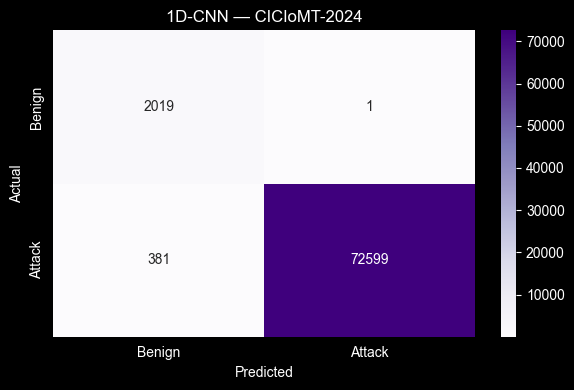


TN: 2019  FP: 1  FN: 381  TP: 72599
Model saved.


In [1]:
# ══════════════════════════════════════════════════════════════════════════
# DAY 16 SUMMARY — 1D-CNN on CICIoMT-2024
# ══════════════════════════════════════════════════════════════════════════
#
# MODEL: 1D Convolutional Neural Network
# Config: 2x Conv1D (64/128 filters), GlobalMaxPool, Dense 64, Dropout 0.3
#
# RESULTS:
#   F1:        0.9974
#   AUC-ROC:   0.9994
#   Precision: 1.0000  ← perfect, zero false alarms
#   Recall:    0.9948
#   Accuracy:  0.9949
#
# KEY OBSERVATION:
#   Perfect precision again — same pattern as MLP. Slightly below MLP
#   on F1 (0.9974 vs 0.9979). CNN gains no advantage over MLP on
#   tabular data — consistent with CIC-IoT-2023 findings.
#
# CROSS-DATASET COMPARISON (1D-CNN):
#   CIC-IoT-2023:  F1=0.9780  AUC=0.9922
#   CICIoMT-2024:  F1=0.9974  AUC=0.9994  ← +0.0194 F1 improvement
# ══════════════════════════════════════════════════════════════════════════